<a href="https://colab.research.google.com/github/knikhilbharath/Pytorch/blob/main/Linear%20regresion_custom%20modules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Custom Modules**

In [76]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np


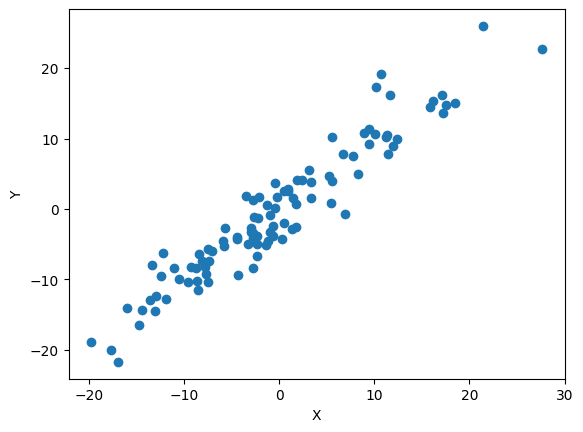

In [77]:
X = torch.randn(100, 1)*10
y = X + 3*torch.randn(100, 1)
plt.plot(X.numpy(), y.numpy(), 'o')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [78]:
class LR(nn.Module):
  def __init__ (self, input_size, output_size):
    super().__init__()
    self.linear = nn.Linear(input_size, output_size)
  def forward(self, x):
    pred = self.linear(x)
    return pred

In [79]:
torch.manual_seed(1)
model = LR(1, 1)
print(list(model.parameters()))
print(model)

[Parameter containing:
tensor([[0.5153]], requires_grad=True), Parameter containing:
tensor([-0.4414], requires_grad=True)]
LR(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [80]:
[w, b] = model.parameters()
def get_params():
  return (w[0][0].item(), b[0].item())

In [81]:
def plot_fit(title):
  plt.title = title
  w1, b1 = get_params()
  x1 = np.array([-30, 30])
  y1 = w1 * x1 + b1
  plt.plot(x1, y1, 'r')
  plt.scatter(X, y)
  plt.show()

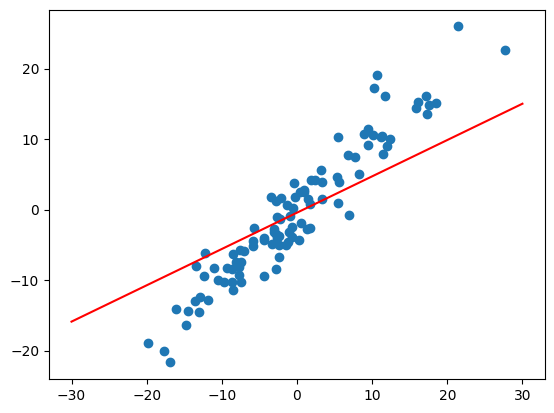

In [82]:
plot_fit('Initial Model')

In [83]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

In [84]:
epochs = 100
losses = []
for i in range(epochs):
  y_pred = model.forward(X)
  loss = criterion(y_pred, y)
  print("epoch:", i, "loss:", loss.item())

  losses.append(loss)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

epoch: 0 loss: 26.4892635345459
epoch: 1 loss: 19.814558029174805
epoch: 2 loss: 15.61193561553955
epoch: 3 loss: 12.965537071228027
epoch: 4 loss: 11.298819541931152
epoch: 5 loss: 10.248849868774414
epoch: 6 loss: 9.587152481079102
epoch: 7 loss: 9.169901847839355
epoch: 8 loss: 8.906560897827148
epoch: 9 loss: 8.740133285522461
epoch: 10 loss: 8.634736061096191
epoch: 11 loss: 8.56778621673584
epoch: 12 loss: 8.525060653686523
epoch: 13 loss: 8.49760913848877
epoch: 14 loss: 8.479793548583984
epoch: 15 loss: 8.468066215515137
epoch: 16 loss: 8.460188865661621
epoch: 17 loss: 8.454756736755371
epoch: 18 loss: 8.450883865356445
epoch: 19 loss: 8.448007583618164
epoch: 20 loss: 8.445777893066406
epoch: 21 loss: 8.443970680236816
epoch: 22 loss: 8.4424467086792
epoch: 23 loss: 8.44111442565918
epoch: 24 loss: 8.439918518066406
epoch: 25 loss: 8.438824653625488
epoch: 26 loss: 8.43780517578125
epoch: 27 loss: 8.436847686767578
epoch: 28 loss: 8.435940742492676
epoch: 29 loss: 8.435076713

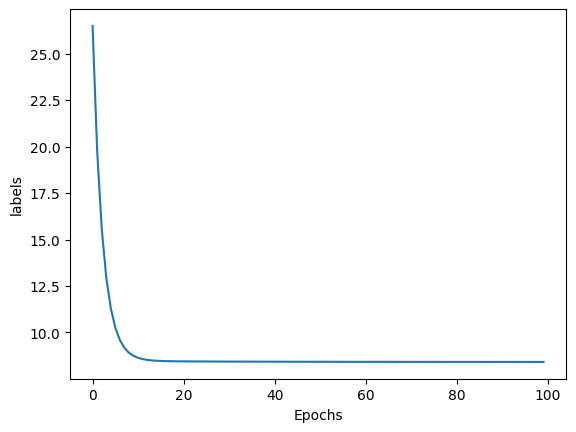

In [86]:
plt.plot(range(epochs), [loss.detach().numpy() for loss in losses]) # Detach tensors before converting to numpy
plt.xlabel('Epochs')
plt.ylabel('labels')
plt.show()

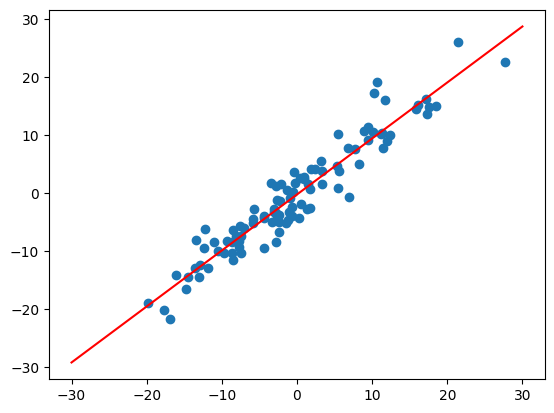

In [87]:
plot_fit('trained model')